In [2]:
import os
import pandas as pd

# Path to MERGED_CSV folder
data_path = "../extracted/MERGED_CSV"

files = os.listdir(data_path)
print(f"Files found: {len(files)}")
print(files[:10])

Files found: 63
['Merged27.csv', 'Merged33.csv', 'Merged32.csv', 'Merged26.csv', 'Merged18.csv', 'Merged30.csv', 'Merged24.csv', 'Merged25.csv', 'Merged31.csv', 'Merged19.csv']


In [3]:
# Load all 63 files into one dataframe
import glob

all_files = glob.glob(os.path.join(data_path, "*.csv"))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in all_files], ignore_index=True)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (45019243, 40)
Columns: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']


In [4]:
# Basic overview
print("=== SHAPE ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== LABEL DISTRIBUTION ===")
print(df['Label'].value_counts())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "total missing values")

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== SHAPE ===
Rows: 45,019,243
Columns: 40

=== LABEL DISTRIBUTION ===
Label
DDOS-ICMP_FLOOD            6893259
DDOS-UDP_FLOOD             5181027
DDOS-TCP_FLOOD             4306086
DDOS-PSHACK_FLOOD          3920372
DDOS-SYN_FLOOD             3886130
DDOS-RSTFINFLOOD           3872808
DDOS-SYNONYMOUSIP_FLOOD    3445659
DOS-UDP_FLOOD              3177323
DOS-TCP_FLOOD              2558256
DOS-SYN_FLOOD              1942176
BENIGN                     1051373
MIRAI-GREETH_FLOOD          949381
MIRAI-UDPPLAIN              852695
MIRAI-GREIP_FLOOD           719655
DDOS-ICMP_FRAGMENTATION     433157
VULNERABILITYSCAN           357583
MITM-ARPSPOOFING            294469
DDOS-UDP_FRAGMENTATION      274909
DDOS-ACK_FRAGMENTATION      272793
DNS_SPOOFING                171468
RECON-HOSTDISCOVERY         128677
RECON-OSSCAN                 93970
RECON-PORTSCAN               78730
DOS-HTTP_FLOOD               68799
DDOS-HTTP_FLOOD              27597
DDOS-SLOWLORIS               22400
DICTIONARYBRU

In [5]:
# Group into attack categories
category_map = {
    'BENIGN': 'Benign',
    'DDOS-ICMP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS',
    'DDOS-TCP_FLOOD': 'DDoS', 'DDOS-PSHACK_FLOOD': 'DDoS',
    'DDOS-SYN_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS', 'DDOS-ICMP_FRAGMENTATION': 'DDoS',
    'DDOS-UDP_FRAGMENTATION': 'DDoS', 'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-HTTP_FLOOD': 'DDoS', 'DDOS-SLOWLORIS': 'DDoS',
    'DOS-UDP_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS',
    'DOS-SYN_FLOOD': 'DoS', 'DOS-HTTP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai',
    'MIRAI-GREIP_FLOOD': 'Mirai',
    'RECON-HOSTDISCOVERY': 'Recon', 'RECON-OSSCAN': 'Recon',
    'RECON-PORTSCAN': 'Recon', 'RECON-PINGSWEEP': 'Recon',
    'VULNERABILITYSCAN': 'Recon',
    'MITM-ARPSPOOFING': 'Spoofing', 'DNS_SPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'BruteForce',
    'BROWSERHIJACKING': 'Web', 'COMMANDINJECTION': 'Web',
    'SQLINJECTION': 'Web', 'XSS': 'Web',
    'BACKDOOR_MALWARE': 'Web', 'UPLOADING_ATTACK': 'Web',
}

df['Category'] = df['Label'].map(category_map)

print("=== CATEGORY DISTRIBUTION ===")
print(df['Category'].value_counts())
print(f"\nTotal categories: {df['Category'].nunique()}")

=== CATEGORY DISTRIBUTION ===
Category
DDoS          32536197
DoS            7746554
Mirai          2521731
Benign         1051373
Recon           661121
Spoofing        465937
Web              23799
BruteForce       12522
Name: count, dtype: int64

Total categories: 8


In [6]:
df.shape

(45019243, 41)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# === 1. INF VALUES ===
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum()
print("=== INF VALUES ===")
print(inf_counts[inf_counts > 0])

# === 2. DUPLICATES ===
dupes = df.duplicated().sum()
print(f"\n=== DUPLICATES ===")
print(f"{dupes:,} duplicate rows")

# === 3. CONSTANT COLUMNS ===
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f"\n=== CONSTANT COLUMNS ===")
print(constant_cols if constant_cols else "None found")

=== INF VALUES ===
Rate    991
dtype: int64

=== DUPLICATES ===
24,013,505 duplicate rows

=== CONSTANT COLUMNS ===
None found


In [8]:
# Check duplicate distribution
df_clean = df.drop_duplicates()
print(f"Original rows:    {len(df):,}")
print(f"After dedup:      {len(df_clean):,}")
print(f"Removed:          {len(df) - len(df_clean):,}")

print("\n=== LABEL DISTRIBUTION AFTER DEDUP ===")
print(df_clean['Label'].value_counts())

print("\n=== CATEGORY DISTRIBUTION AFTER DEDUP ===")
print(df_clean['Category'].value_counts())

Original rows:    45,019,243
After dedup:      21,005,738
Removed:          24,013,505

=== LABEL DISTRIBUTION AFTER DEDUP ===
Label
DDOS-UDP_FLOOD             1964173
DDOS-ICMP_FLOOD            1907584
DOS-UDP_FLOOD              1851659
DDOS-SYN_FLOOD             1764642
DDOS-PSHACK_FLOOD          1641916
DDOS-TCP_FLOOD             1560659
DDOS-RSTFINFLOOD           1255800
DDOS-SYNONYMOUSIP_FLOOD    1171394
DOS-SYN_FLOOD              1138635
DOS-TCP_FLOOD              1120206
BENIGN                     1047367
MIRAI-GREETH_FLOOD          897639
MIRAI-UDPPLAIN              767337
MIRAI-GREIP_FLOOD           694332
DDOS-ICMP_FRAGMENTATION     431181
VULNERABILITYSCAN           356329
DDOS-UDP_FRAGMENTATION      273416
DDOS-ACK_FRAGMENTATION      271558
MITM-ARPSPOOFING            269062
DNS_SPOOFING                167022
RECON-HOSTDISCOVERY         127870
RECON-OSSCAN                 92327
RECON-PORTSCAN               76790
DOS-HTTP_FLOOD               68445
DDOS-HTTP_FLOOD            

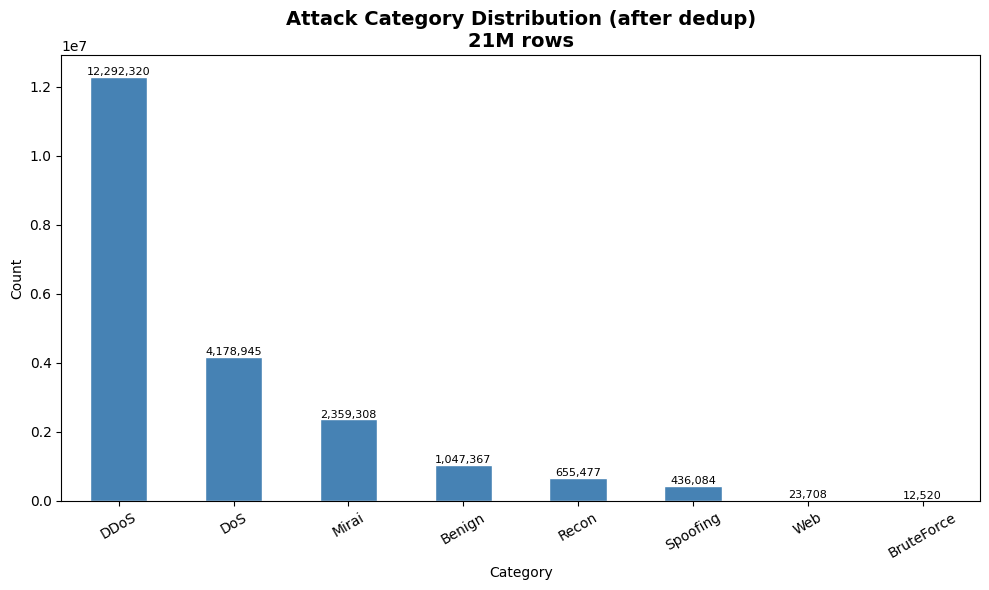

Saved: category_distribution.png


In [9]:
# Save category distribution plot
fig, ax = plt.subplots(figsize=(10, 6))
cat_counts = df_clean['Category'].value_counts()
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Attack Category Distribution (after dedup)\n21M rows', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

# Add counts on bars
for i, v in enumerate(cat_counts):
    ax.text(i, v + 50000, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()
print("Saved: category_distribution.png")

In [10]:
# Fix Inf values and drop missing, work on df_clean
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()

print(f"Rows after fixing Inf + NaN: {len(df_clean):,}")

# Feature statistics
stats = df_clean.drop(columns=['Label', 'Category']).describe().T
stats = stats[['mean', 'std', 'min', 'max']]
print("\n=== FEATURE STATISTICS ===")
print(stats.to_string())

# Save stats to CSV
stats.to_csv('feature_statistics.csv')
print("\nSaved: feature_statistics.csv")

Rows after fixing Inf + NaN: 21,005,152

=== FEATURE STATISTICS ===
                         mean            std         min           max
Header_Length       14.022969       9.085981    0.000000  6.000000e+01
Protocol Type       11.235909      11.468765    0.000000  4.700000e+01
Time_To_Live        69.413359      20.664107    0.000000  2.550000e+02
Rate             19238.564456   31067.527887    0.000013  1.572864e+07
fin_flag_number      0.061739       0.234749    0.000000  1.000000e+00
syn_flag_number      0.195040       0.384731    0.000000  1.000000e+00
rst_flag_number      0.074058       0.245408    0.000000  1.000000e+00
psh_flag_number      0.093043       0.258343    0.000000  1.000000e+00
ack_flag_number      0.168225       0.336026    0.000000  1.000000e+00
ece_flag_number      0.000061       0.002960    0.000000  1.000000e+00
cwr_flag_number      0.000031       0.002054    0.000000  1.000000e+00
ack_count           10.280025      26.545589    0.000000  1.000000e+02
syn_count

In [13]:
output_path = '../extracted/ciciot_clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {df_clean.shape}")
print(f"\nEDA Complete. Summary:")
print(f"  Original rows:     45,019,243")
print(f"  After dedup:       21,005,738")
print(f"  After Inf/NaN fix: {len(df_clean):,}")
print(f"  Features:          {len(df_clean.columns) - 2}")
print(f"  Attack classes:    {df_clean['Label'].nunique()}")
print(f"  Categories:        {df_clean['Category'].nunique()}")

Saved: ../extracted/ciciot_clean.csv
Shape: (21005152, 41)

EDA Complete. Summary:
  Original rows:     45,019,243
  After dedup:       21,005,738
  After Inf/NaN fix: 21,005,152
  Features:          39
  Attack classes:    34
  Categories:        8
